## EfficientNet-B0 Classification for Indian Paintings

### Dataset Download

The Indian Paintings Dataset is downloaded from KaggleHub for this experiment.

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ajg117/indian-paintings-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'indian-paintings-dataset' dataset.
Path to dataset files: /kaggle/input/indian-paintings-dataset


### Library Imports

Required libraries are imported for data handling, model training, and evaluation.

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, random_split, Dataset

import torchvision
from torchvision import datasets, transforms, models

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

import seaborn as sns

### Device Configuration



In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: Tesla T4


### Dataset Path Configuration

### Dataset Inspection

The dataset directory structure and contents are inspected.

In [ ]:
dataset_path = path

print("Dataset path:", dataset_path)

Dataset path: /kaggle/input/indian-paintings-dataset


In [ ]:
print("\nContents of dataset directory:")

for item in os.listdir(dataset_path):
    full_path = os.path.join(dataset_path, item)

    if os.path.isdir(full_path):
        print("[DIR] ", item)
    else:
        print("[FILE]", item)


Contents of dataset directory:
[DIR]  kerala mural
[DIR]  kalighat painting
[FILE] LICENSE
[DIR]  warli painting
[DIR]  kangra painting
[DIR]  mandana art drawing
[DIR]  madhubani painting
[FILE] classes.csv
[DIR]  pichwai painting
[DIR]  gond painting


### Dataset Loading and Class Inspection

The dataset is loaded, and the class labels are verified.

In [ ]:
base_dataset = datasets.ImageFolder(
    root=dataset_path,
    transform=None
)

print("Total images:", len(base_dataset))
print("Number of classes:", len(base_dataset.classes))

print("\nClasses:")
for idx, class_name in enumerate(base_dataset.classes):
    print(idx, ":", class_name)

print("\nClass to index:")
print(base_dataset.class_to_idx)

Total images: 953
Number of classes: 8

Classes:
0 : gond painting
1 : kalighat painting
2 : kangra painting
3 : kerala mural
4 : madhubani painting
5 : mandana art drawing
6 : pichwai painting
7 : warli painting

Class to index:
{'gond painting': 0, 'kalighat painting': 1, 'kangra painting': 2, 'kerala mural': 3, 'madhubani painting': 4, 'mandana art drawing': 5, 'pichwai painting': 6, 'warli painting': 7}


### Image Transformations and Augmentations

Training augmentation is applied for robustness, while validation/test preprocessing remains deterministic.

In [ ]:
NUM_CLASSES = len(base_dataset.classes)

print("Number of classes:", NUM_CLASSES)

assert NUM_CLASSES == 8, (
    f"Expected 8 classes based on the reference experiment, "
    f"but found {NUM_CLASSES}."
)

Number of classes: 8


In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(15),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


test_transform = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

### Train/Validation/Test Split

The dataset is split into 70% training, 15% validation, and 15% test subsets with a random seed of 42, mirroring the baseline experiment.

In [ ]:
total_size = len(base_dataset)

train_size = int(0.70 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size

generator = torch.Generator().manual_seed(42)

train_subset, val_subset, test_subset = random_split(
    base_dataset,
    [train_size, val_size, test_size],
    generator=generator
)

print("Total images:", total_size)
print("Training images:", len(train_subset))
print("Validation images:", len(val_subset))
print("Testing images:", len(test_subset))

Total images: 953
Training images: 667
Validation images: 142
Testing images: 144


### Transform Assignment to Dataset Subsets

The `TransformSubset` class is used to apply specific transformations to each dataset split.

In [ ]:
class TransformSubset(Dataset):

    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, index):

        image, label = self.subset[index]

        if self.transform:
            image = self.transform(image)

        return image, label

### Dataset Subset Application

In [ ]:
train_dataset = TransformSubset(
    train_subset,
    train_transform
)

val_dataset = TransformSubset(
    val_subset,
    test_transform
)

test_dataset = TransformSubset(
    test_subset,
    test_transform
)

print("Train dataset:", len(train_dataset))
print("Validation dataset:", len(val_dataset))
print("Test dataset:", len(test_dataset))

Train dataset: 667
Validation dataset: 142
Test dataset: 144


### DataLoaders

DataLoaders are configured to provide batched data for training, validation, and testing.

In [ ]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

print("DataLoaders created.")
print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

DataLoaders created.
Train batches: 21
Validation batches: 5
Test batches: 5


### Batch Verification

A sample batch is loaded to verify correct dimensions and labels.

In [ ]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("First 10 labels:", labels[:10])

Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])
First 10 labels: tensor([6, 6, 5, 2, 5, 7, 3, 2, 5, 7])


### Sample Image Visualization

Sample images from a training batch are visualized to confirm preprocessing and augmentation.

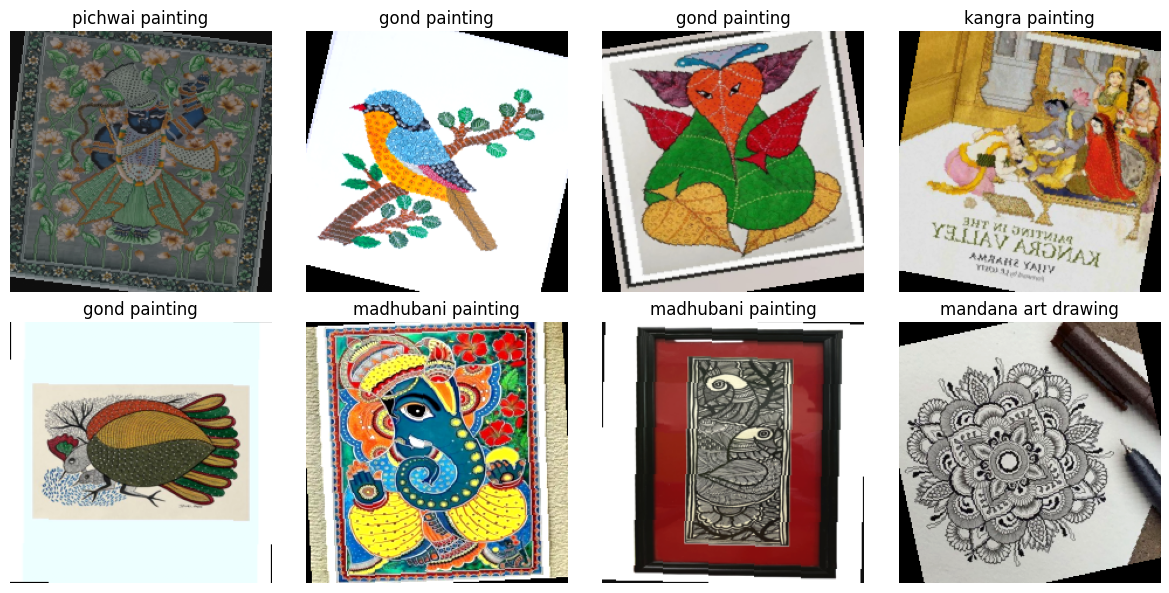

In [ ]:
mean = torch.tensor(
    [0.485, 0.456, 0.406]
).view(3, 1, 1)

std = torch.tensor(
    [0.229, 0.224, 0.225]
).view(3, 1, 1)

images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i, ax in enumerate(axes.flat):

    image = images[i].cpu()

    image = image * std + mean

    image = torch.clamp(image, 0, 1)

    ax.imshow(image.permute(1, 2, 0))

    ax.set_title(
        base_dataset.classes[labels[i].item()]
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

### Pretrained EfficientNet-B0 Model Loading

An ImageNet-pretrained EfficientNet-B0 model is loaded as the backbone for transfer learning.

In [ ]:
weights = models.EfficientNet_B0_Weights.DEFAULT

model = models.efficientnet_b0(
    weights=weights
)

print(model)

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

### Classification Head Configuration

The original classification head is replaced with a custom one suitable for 8 painting classes.

In [ ]:
num_features = model.classifier[1].in_features

print("EfficientNet-B0 feature size:", num_features)

model.classifier = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(num_features, NUM_CLASSES)
)

model = model.to(device)

print("\nNew classifier:")
print(model.classifier)

EfficientNet-B0 feature size: 1280

New classifier:
Sequential(
  (0): Dropout(p=0.4, inplace=False)
  (1): Linear(in_features=1280, out_features=8, bias=True)
)


### Feature Extractor Freezing (Stage 1)

The EfficientNet feature extractor layers are frozen to preserve pre-trained weights during initial training.

In [ ]:
for param in model.parameters():
    param.requires_grad = False

for param in model.classifier.parameters():
    param.requires_grad = True

### Verifying Trainable Parameters

In [ ]:
trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

total_params = sum(
    p.numel()
    for p in model.parameters()
)

print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)

Total parameters: 4017796
Trainable parameters: 10248


### Loss Function, Optimizer, and Scheduler

These components are set up to control model optimization during training.

In [ ]:
# Lost and classifier
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.classifier.parameters(),
    lr=0.001
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

### Training Function

This function handles the forward pass, loss calculation, backpropagation, and weight updates for one epoch.

In [ ]:
# Training function
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device
):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += (
            loss.item() * images.size(0)
        )

        _, predicted = torch.max(
            outputs,
            1
        )

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()

    epoch_loss = running_loss / total

    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

### Validation Function

This function evaluates the model's performance on a given dataset without updating weights.

In [ ]:
# Validation function
def validate(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            running_loss += (
                loss.item() * images.size(0)
            )

            _, predicted = torch.max(
                outputs,
                1
            )

            total += labels.size(0)

            correct += (
                predicted == labels
            ).sum().item()

    epoch_loss = running_loss / total

    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

### Stage 1 — Initial Training

The model's classification head is trained with the feature extractor frozen, and the best model is checkpointed based on validation accuracy.

In [ ]:
# Training classifier
# Initial training

EPOCHS = 10

train_losses = []
train_accuracies = []

val_losses = []
val_accuracies = []

best_val_accuracy = -float("inf")

best_model_path = "best_efficientnet_b0_indian_paintings.pth"

for epoch in range(EPOCHS):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc = validate(
        model,
        val_loader,
        criterion,
        device
    )

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    scheduler.step(val_acc)

    print(
        f"Epoch [{epoch + 1}/{EPOCHS}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_acc:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_acc:.4f}"
    )

    if val_acc > best_val_accuracy:

        best_val_accuracy = val_acc

        torch.save(
            model.state_dict(),
            best_model_path
        )

        print("✓ Best model saved")

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [1/10] Train Loss: 1.8035 Train Acc: 0.3253 Val Loss: 1.5990 Val Acc: 0.4366
✓ Best model saved


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [2/10] Train Loss: 1.3483 Train Acc: 0.6057 Val Loss: 1.2934 Val Acc: 0.6338
✓ Best model saved


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


...

Epoch [8/10] Train Loss: 0.6801 Train Acc: 0.8246 Val Loss: 0.8152 Val Acc: 0.7465
✓ Best model saved


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [9/10] Train Loss: 0.6361 Train Acc: 0.8366 Val Loss: 0.8020 Val Acc: 0.7254


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [10/10] Train Loss: 0.6082 Train Acc: 0.8381 Val Loss: 0.7690 Val Acc: 0.7394


### Stage 2 — EfficientNet Fine-Tuning: Unfreezing Layers

Final EfficientNet feature stages are unfrozen to allow adaptation to the painting dataset.

In [ ]:
# Freeze the entire EfficientNet feature extractor
for param in model.features.parameters():
    param.requires_grad = False

# Unfreeze the final EfficientNet feature stages
for param in model.features[7:].parameters():
    param.requires_grad = True

# Keep the classifier trainable
for param in model.classifier.parameters():
    param.requires_grad = True

### Verifying Trainable Layers for Fine-Tuning

In [ ]:
print("Trainable layers:")

for name, param in model.named_parameters():
    if param.requires_grad:
        print(name)

Trainable layers:
features.7.0.block.0.0.weight
features.7.0.block.0.1.weight
features.7.0.block.0.1.bias
features.7.0.block.1.0.weight
features.7.0.block.1.1.weight
features.7.0.block.1.1.bias
features.7.0.block.2.fc1.weight
features.7.0.block.2.fc1.bias
features.7.0.block.2.fc2.weight
features.7.0.block.2.fc2.bias
features.7.0.block.3.0.weight
features.7.0.block.3.1.weight
features.7.0.block.3.1.bias
features.8.0.weight
features.8.1.weight
features.8.1.bias
classifier.1.weight
classifier.1.bias


### Re-initializing Optimizer for Fine-Tuning

In [ ]:
optimizer = optim.Adam(
    filter(
        lambda p: p.requires_grad,
        model.parameters()
    ),
    lr=0.0001
)

### Stage 2 — Fine-Tuning Execution

The model undergoes fine-tuning with unfrozen layers and a reduced learning rate.

**Unfreeze final EfficientNet blocks**

In [ ]:
# train for more 5 epoch for fine-tuning
EPOCHS_FINE = 5

for epoch in range(EPOCHS_FINE):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc = validate(
        model,
        val_loader,
        criterion,
        device
    )

    # Keep complete training history
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(
        f"Fine-tuning Epoch [{epoch + 1}/{EPOCHS_FINE}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_acc:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_acc:.4f}"
    )

    if val_acc > best_val_accuracy:

        best_val_accuracy = val_acc

        torch.save(
            model.state_dict(),
            best_model_path
        )

        print("✓ Best model saved")

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Fine-tuning Epoch [1/5] Train Loss: 0.5926 Train Acc: 0.8336 Val Loss: 0.7015 Val Acc: 0.7606
✓ Best model saved


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Fine-tuning Epoch [2/5] Train Loss: 0.5060 Train Acc: 0.8831 Val Loss: 0.6770 Val Acc: 0.7887
✓ Best model saved


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Fine-tuning Epoch [3/5] Train Loss: 0.4544 Train Acc: 0.8666 Val Loss: 0.6413 Val Acc: 0.7887


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Fine-tuning Epoch [4/5] Train Loss: 0.3908 Train Acc: 0.9160 Val Loss: 0.6198 Val Acc: 0.8099
✓ Best model saved


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Fine-tuning Epoch [5/5] Train Loss: 0.3816 Train Acc: 0.8951 Val Loss: 0.6015 Val Acc: 0.8099


### Training Curves: Accuracy

Training and validation accuracy over epochs are visualized.

**Accuracy**

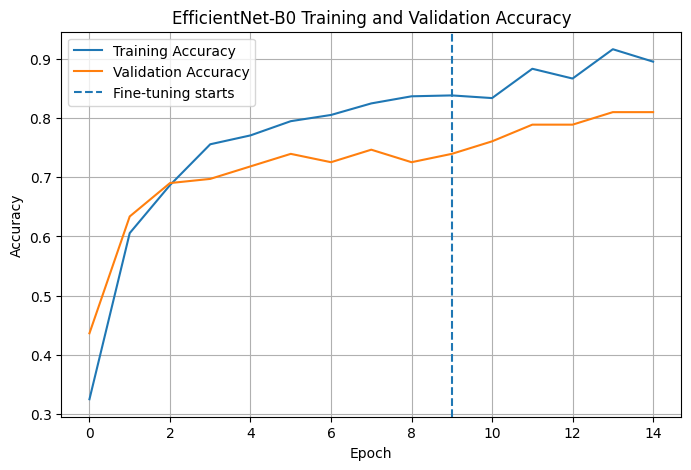

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    train_accuracies,
    label="Training Accuracy"
)

plt.plot(
    val_accuracies,
    label="Validation Accuracy"
)

plt.axvline(
    x=EPOCHS - 1,
    linestyle="--",
    label="Fine-tuning starts"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "EfficientNet-B0 Training and Validation Accuracy"
)

plt.legend()
plt.grid()

plt.show()

### Training Curves: Loss

Training and validation loss over epochs are visualized.

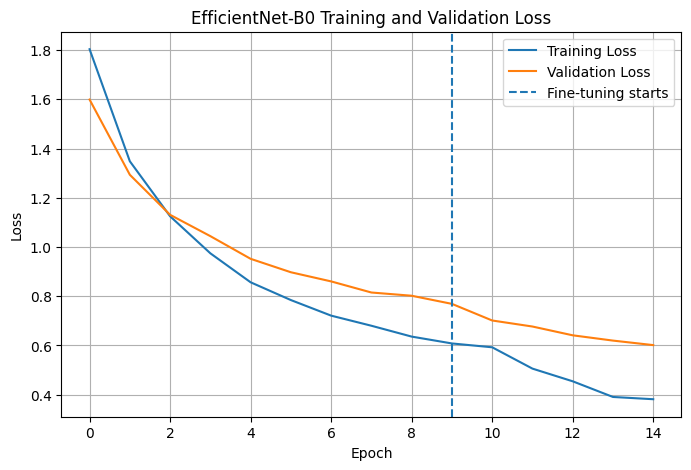

In [ ]:
# Loss

plt.figure(figsize=(8, 5))

plt.plot(
    train_losses,
    label="Training Loss"
)

plt.plot(
    val_losses,
    label="Validation Loss"
)

plt.axvline(
    x=EPOCHS - 1,
    linestyle="--",
    label="Fine-tuning starts"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "EfficientNet-B0 Training and Validation Loss"
)

plt.legend()
plt.grid()

plt.show()

### Best Model Checkpoint Loading

The model with the best validation performance is loaded for final evaluation.

In [ ]:
# load best model

model.load_state_dict(
    torch.load(
        best_model_path,
        map_location=device
    )
)

model = model.to(device)

print(
    f"Best validation accuracy: "
    f"{best_val_accuracy:.4f}"
)

Best validation accuracy: 0.8099


### Test Set Evaluation: Prediction Collection

Predictions are collected from the held-out test set.

In [ ]:
# Final best evaluations
model.eval()

all_labels = []
all_predictions = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, predictions = torch.max(
            outputs,
            1
        )

        all_labels.extend(
            labels.numpy()
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


### Test Accuracy Calculation

The overall accuracy on the test set is calculated.

In [ ]:
# Test accuracy
test_accuracy = accuracy_score(
    all_labels,
    all_predictions
)

print(
    f"EfficientNet-B0 Test Accuracy: "
    f"{test_accuracy:.4f}"
)

print(
    f"Percentage: "
    f"{test_accuracy * 100:.2f}%"
)

EfficientNet-B0 Test Accuracy: 0.8472
Percentage: 84.72%


### Classification Report

Precision, recall, F1-score, and support are reported for each painting class.

In [ ]:
# Classification report
report = classification_report(
    all_labels,
    all_predictions,
    target_names=base_dataset.classes,
    digits=4
)

print(report)

                     precision    recall  f1-score   support

      gond painting     0.7778    0.8750    0.8235        16
  kalighat painting     0.8936    0.9545    0.9231        44
    kangra painting     1.0000    0.8571    0.9231        14
       kerala mural     0.8750    0.6364    0.7368        11
 madhubani painting     0.5385    0.7778    0.6364         9
mandana art drawing     0.7333    0.9167    0.8148        12
   pichwai painting     1.0000    0.7917    0.8837        24
     warli painting     0.8333    0.7143    0.7692        14

           accuracy                         0.8472       144
          macro avg     0.8314    0.8154    0.8138       144
       weighted avg     0.8660    0.8472    0.8493       144



### Confusion Matrix Visualization

The confusion matrix is displayed to inspect class-level prediction patterns and misclassifications.

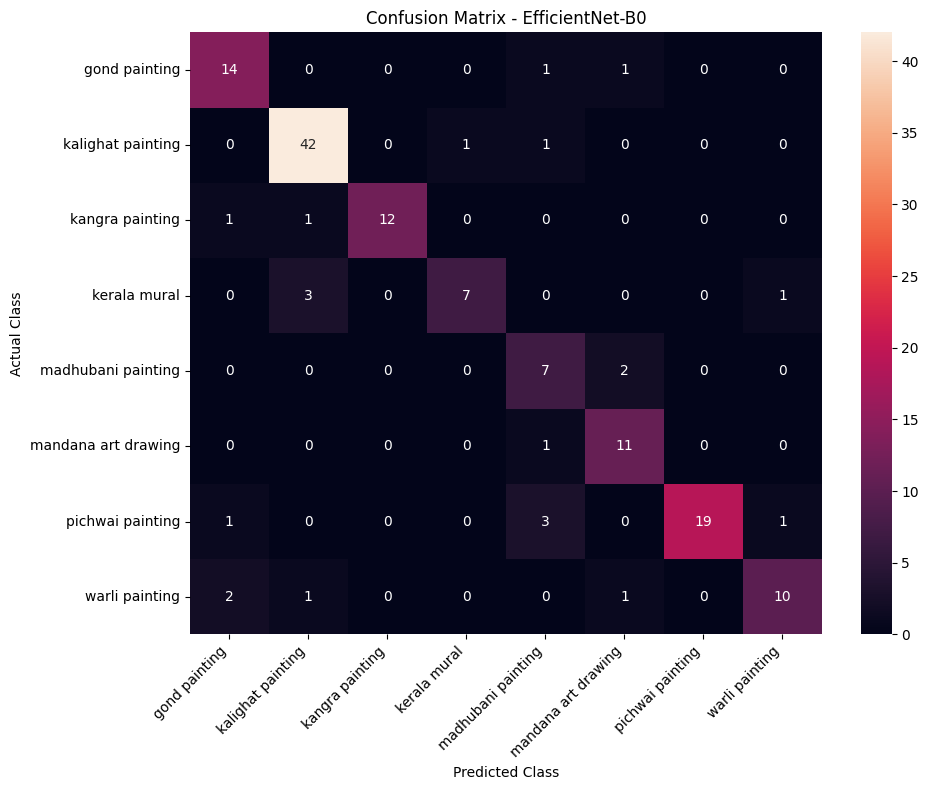

In [ ]:
# Generate confusion matrix
cm = confusion_matrix(
    all_labels,
    all_predictions
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=base_dataset.classes,
    yticklabels=base_dataset.classes
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.title(
    "Confusion Matrix - EfficientNet-B0"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.yticks(rotation=0)

plt.tight_layout()

plt.show()

### Final Metrics Summary

Main evaluation metrics are summarized for comparison with other algorithms.

In [ ]:
# final result summary
from sklearn.metrics import precision_score, recall_score, f1_score

macro_precision = precision_score(
    all_labels,
    all_predictions,
    average="macro",
    zero_division=0
)

macro_recall = recall_score(
    all_labels,
    all_predictions,
    average="macro",
    zero_division=0
)

macro_f1 = f1_score(
    all_labels,
    all_predictions,
    average="macro",
    zero_division=0
)

weighted_f1 = f1_score(
    all_labels,
    all_predictions,
    average="weighted",
    zero_division=0
)

results = pd.DataFrame({
    "Metric": [
        "Test Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1",
        "Weighted F1"
    ],
    "Score": [
        test_accuracy,
        macro_precision,
        macro_recall,
        macro_f1,
        weighted_f1
    ]
})

results

,Metric,Score
0,Test Accuracy,0.847222
1,Macro Precision,0.831440
2,Macro Recall,0.815431
3,Macro F1,0.813832
4,Weighted F1,0.849332
